Requirements
- ucimlrepo


In [4]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
abalone = fetch_ucirepo(id=1) 
  
# data (as pandas dataframes) 
X = abalone.data.features 
y = abalone.data.targets 

In [5]:
X.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


# Exploratory Data Analysis

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### 1. Correlation between variables

Text(0.5, 0, 'Figure 1: Features Correlations')

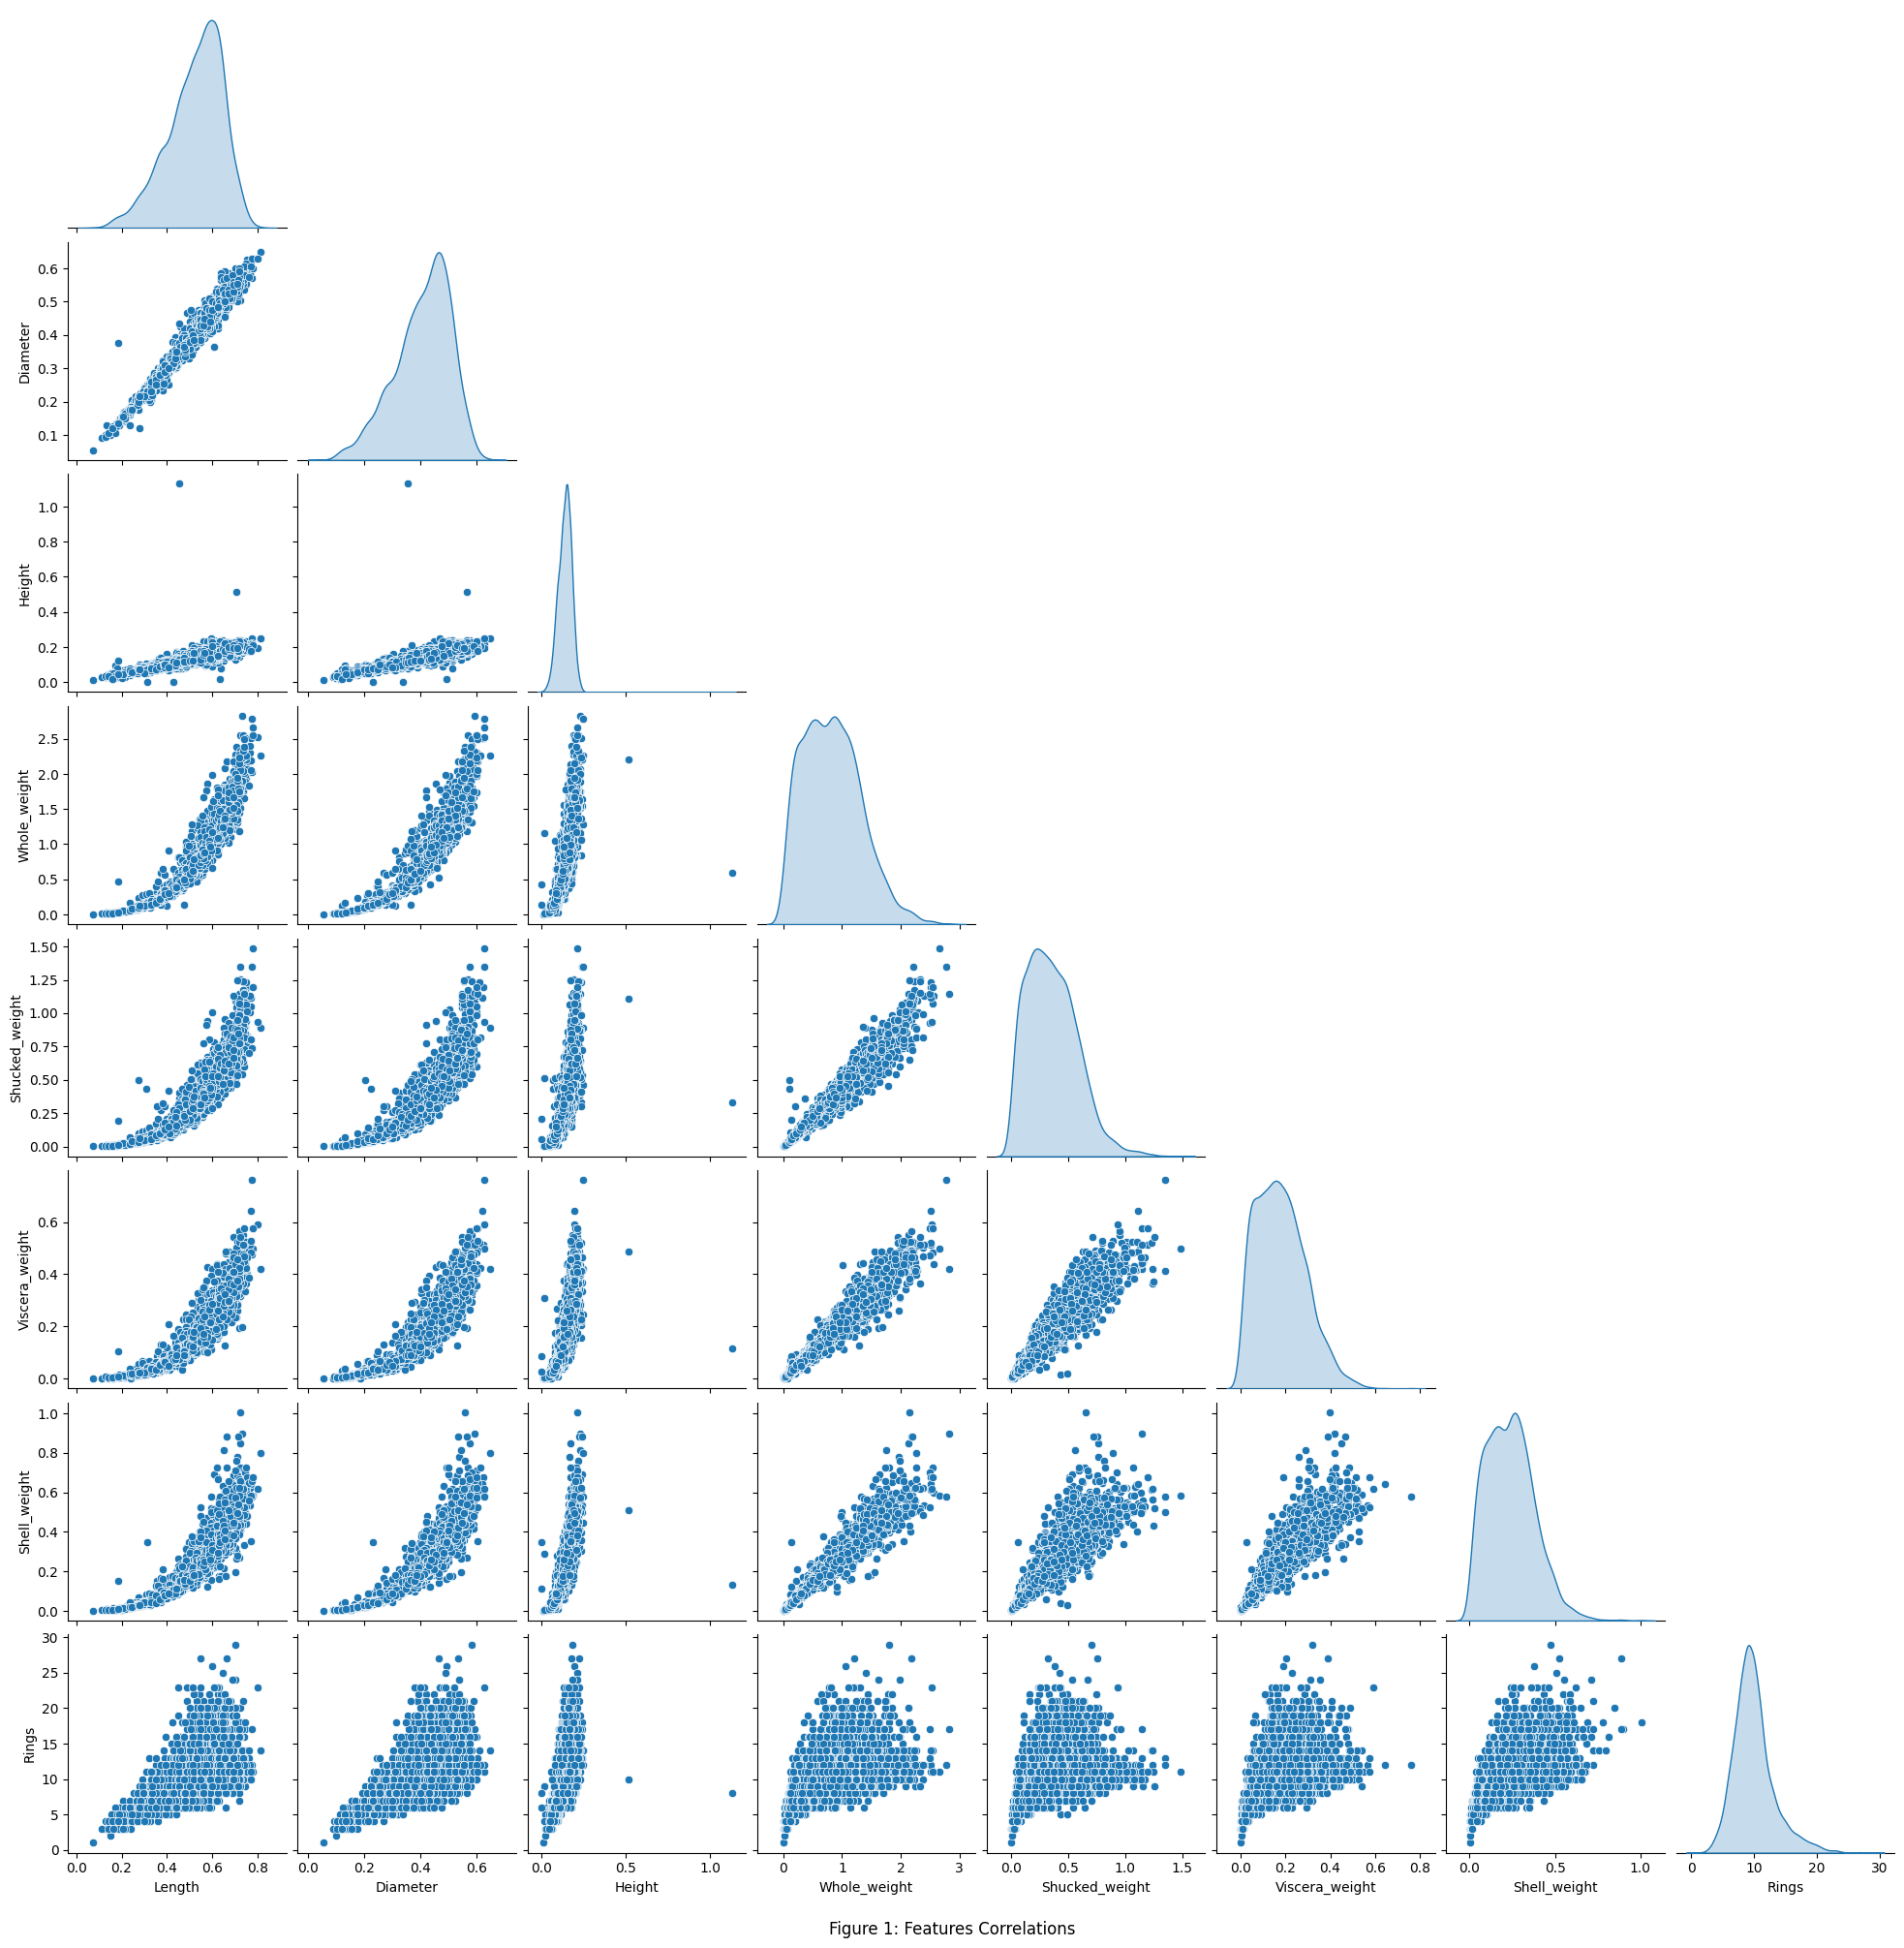

In [11]:
# features_corr = X.corr()

df: pd.DataFrame = pd.concat([X, y], axis=1)

grid: sns.PairGrid = sns.pairplot(df, corner=True, diag_kind="kde")
grid.fig.suptitle("Figure 1: Features Correlations", y=0)

After observing the figure 1, we can see that the data are mostly related to each other (both linear and nonlinear relationships). Therefore, if we build a Linear Regression model with all features, multicollinearity will occur. This makes it difficult for the model to perform well when used on untrained data. To address this issue, we use the PCA model to transform the data and consider selecting the number of principal components to achieve the best results.

### 2. Observing the relationship between explanatory variables and the dependent variable

From Figure 1, we can see that the explanatory variables tend to have a nonlinear relationship with the dependent variable. In order to observe this more clearly, we use Hexbin plots.


## Preprocessing

1. Convert qualitative data to quantitative data using One-hot Encoding.

In [12]:

# Get categorical columns
cat_features = df.columns[df.dtypes==object]

# Drop categorical columns for transform numerical features with PCA
cat_cols = df.loc[:, cat_features]
df.drop(columns=cat_features, inplace=True)

df.head()

# df_encoded = pd.get_dummies(data=df, columns=["Sex",], drop_first=True, dtype=int)
# df_encoded.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA

scaler = StandardScaler()
scaler.fit(df)
df_scaled = pd.DataFrame(scaler.transform(df), columns=df.columns)

df_scaled.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,-0.574558,-0.432149,-1.064424,-0.641898,-0.607685,-0.726212,-0.638217,1.571544
1,-1.448986,-1.439929,-1.183978,-1.230277,-1.170910,-1.205221,-1.212987,-0.910013
2,0.050033,0.122130,-0.107991,-0.309469,-0.463500,-0.356690,-0.207139,-0.289624
3,-0.699476,-0.432149,-0.347099,-0.637819,-0.648238,-0.607600,-0.602294,0.020571
4,-1.615544,-1.540707,-1.423087,-1.272086,-1.215968,-1.287337,-1.320757,-0.910013


In [14]:
# Concatenate the categorical features to the data frame transformed
df_scaled = pd.concat([df_scaled, cat_cols], axis=1)

y_scaled = df_scaled.loc[:, "Rings"]
df_scaled.drop(columns=["Rings"], inplace=True)

# Use one-hot encoding for all categorical features which removed the first attributes
df_encoded = pd.get_dummies(data=df_scaled, columns=cat_features.values, dtype=int, drop_first=True)
df_encoded.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Sex_I,Sex_M
0,-0.574558,-0.432149,-1.064424,-0.641898,-0.607685,-0.726212,-0.638217,0,1
1,-1.448986,-1.439929,-1.183978,-1.230277,-1.170910,-1.205221,-1.212987,0,1
2,0.050033,0.122130,-0.107991,-0.309469,-0.463500,-0.356690,-0.207139,0,0
3,-0.699476,-0.432149,-0.347099,-0.637819,-0.648238,-0.607600,-0.602294,0,1
4,-1.615544,-1.540707,-1.423087,-1.272086,-1.215968,-1.287337,-1.320757,1,0


After scaling the data to center, we can apply the PCA model for dimensionality and multi-coliner reduction. From the plots in Figure 1, we can see that the explanatory variables have a nonlinear relationship with the dependent variable, so we can try both the regular PCA model and the Kernel PCA model to find out which model yields better results.

Text(0.5, 1.0, 'Percent of data retained through the number of principal componets')

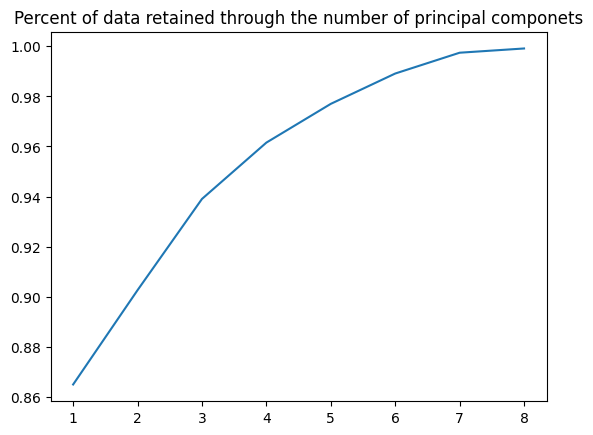

In [15]:
from sklearn.decomposition import PCA, KernelPCA

pca = PCA(n_components=len(df_encoded.columns)-1)
pca.fit(df_encoded)

# For plottings
sns.set_style(style=None)
ax = sns.lineplot(y=pca.explained_variance_ratio_.cumsum(), x=range(1, len(pca.components_) + 1))
ax.set_title("Percent of data retained through the number of principal componets")

So the number of principal components is 4

In [16]:
pca_best = PCA(n_components=4, random_state=48)
pca_best.fit(df_encoded)

cols = [f"Feature {i}" for i in range(4)]

transformed = pca_best.transform(df_encoded)
df_transformed = pd.DataFrame(data=transformed, columns=cols)
df_transformed.head()

,Feature 0,Feature 1,Feature 2,Feature 3
0,-1.676404,-0.201851,-0.937962,-0.344334
1,-3.271538,0.116422,-1.046744,0.231463
2,-0.462562,0.260267,0.141331,-0.467532
3,-1.431105,0.377482,-0.799585,-0.011051
4,-3.719928,-0.334855,0.234526,0.283843


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Train Test Split
train_size = 0.8
X_train, X_test, y_train, y_test = train_test_split(df_transformed.values, y_scaled, train_size=train_size)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


X_train shape: (3341, 4), y_train shape: (3341,)
X_test shape: (836, 4), y_test shape: (836,)


In [24]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

print(f"Training Score: {linreg.score(X_train, y_train)}")
print(f"Testing Score: {linreg.score(X_test, y_test)}")

Training Score: 0.3703736810263659
Testing Score: 0.40118044634636374
